In [1]:
from neuralprophet import NeuralProphet

/home/gwenn/Desktop/Projet/.neuralenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import json
from numpy import median
import pandas as pd
from datetime import timedelta
import numpy as np

def safe_median(values, warn=True):
    '''
    To avoid issues with None or NaN values when computing the median.
    '''
    values = list(values)
    clean = [v for v in values if v is not None and not pd.isna(v)]

    if warn and len(clean) < len(values):
        print(f"{len(values) - len(clean)} ignored values when computing the median.")

    return median(clean) if clean else np.nan
    
def load_jsonl_cleaned(input_file, max_lines = -1, print_progress=True):
    '''
    Load a JSONL file and convert it into a pandas DataFrame.

    :param input_file: path of the JSONL file to load
    :return: pandas DataFrame
    '''
    rows = []
    cpt = 0 # To satisfy the max_lines constraints
    for file in input_file:
        if cpt == max_lines:
            break
        with open(file, 'r', encoding='utf-8') as f:
            total_lines = sum(1 for _ in f) * len(input_file)
            f.seek(0) # Reset file pointer to the beginning after counting lines
            for line in f:
                if cpt == max_lines:
                    break
                cpt += 1
                line = line.strip()
    
                if print_progress and cpt % 100 == 0:
                    print(f"\rTraitement ligne {cpt}/{total_lines}", end="", flush=True)
                if line:
                    item = json.loads(line) ## Load the JSON content
                    content = next(iter(item.values())) ## Get the first value of the dictionary
                    
                    ## Clean the content and taking the median of all the relevant values in qubits
                    content['t1'] = safe_median(list(map(lambda x: x['t1'], content['qubits'].values())))
                    content['t2'] = safe_median(list(map(lambda x: x['t2'], content['qubits'].values())))
                    content['readout_error'] = safe_median(list(map(lambda x: x['readout_error'], content['qubits'].values())))
                    content['prob_meas0_prep1'] = safe_median(list(map(lambda x: x['prob_meas0_prep1'], content['qubits'].values())))
                    content['prob_meas1_prep0'] = safe_median(list(map(lambda x: x['prob_meas1_prep0'], content['qubits'].values())))
                    content.pop('qubits', None)
    
                    ## Clean and taking cols according to the EDA 
                    ### Take the id gates as a referential for single gates metrics
                    if 'id' not in content.get('gates', {}):
                        content['single_gates'] = np.nan
                    else:   
                        content['single_gates'] = safe_median(list(map(lambda x: x['error'], content['gates']['id'].values())))
                    
                    if 'cz' not in content.get('gates', {}):
                        content['cz_error'] = np.nan
                    else:
                        content['cz_error'] = safe_median(list(map(lambda x: x['error'], content['gates']['cz'].values())))
                        
                    if 'rzz' not in content.get('gates', {}):
                        content['rzz_error'] = np.nan
                    else:
                        content['rzz_error'] = safe_median(list(map(lambda x: x['error'], content['gates']['rzz'].values())))
    
                    content.pop('gates', None)
                    
                    rows.append(content)

    df = pd.DataFrame(rows)
    df['calibration_time'] = pd.to_datetime(df['calibration_time'], format='%Y-%m-%d_%H:%M:%S')
    df = df.drop_duplicates(subset=['calibration_time', 'backend'])

    ## Sort each backend by calibration time and backend name
    df_torino = df[df['backend'] == 'ibm_torino'].copy()
    df_torino = df_torino.sort_values('calibration_time').reset_index(drop=True)
    df_torino.ffill(inplace=True)
    
    df_fez = df[df['backend'] == 'ibm_fez'].copy()
    df_fez = df_fez.sort_values('calibration_time').reset_index(drop=True)
    df_fez.ffill(inplace=True)
    
    df_marrakesh = df[df['backend'] == 'ibm_marrakesh'].copy()
    df_marrakesh = df_marrakesh.sort_values('calibration_time').reset_index(drop=True)
    df_marrakesh.ffill(inplace=True)
    
    return df, df_torino, df_fez, df_marrakesh

In [3]:
import os 

files = []
for dirname, _, filenames in os.walk('/home/gwenn/Desktop/Projet/extract/extract_1h'):
    for filename in filenames:
        files.append(f"{dirname}/{filename}")

df, df_torino, df_fez, df_marrakesh = load_jsonl_cleaned(files)

Traitement ligne 11100/11121

In [ ]:
df = load_jsonl_cleaned(["/home/gwenn/Desktop/Projet/dataset/merged_complete.jsonl"])

1 ignored values when computing the median.
1 ignored values when computing the median.
Traitement ligne 1400/59701 ignored values when computing the median.
1 ignored values when computing the median.
Traitement ligne 5400/59701 ignored values when computing the median.
1 ignored values when computing the median.
Traitement ligne 5900/5970

In [49]:
# import torch
import numpy as np
from sklearn.preprocessing import StandardScaler
import torch
from random import randint
import  matplotlib.pyplot as plt

device = torch.device("cpu")

def train_val_test_process_for_train(df, steps = 24):
    data = df
    X_train = []
    y_train = []
    
    X_val = []
    y_val = []
    
    X_test = []
    y_test = []
    
    train_test_split = int(0.8 * len(df))
    train_val_split = int(0.8 * train_test_split)
    
    train_raw = data[:train_val_split]
    val_raw = data[train_val_split:train_test_split]
    test_raw = data[train_test_split:]
    
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_raw) # To normalize the data for the Gru model (needs it)

    val_scaled = scaler.transform(val_raw)
    test_scaled = scaler.transform(test_raw)

    train_data = torch.tensor(train_scaled, dtype=torch.float32)
    val_data = torch.tensor(val_scaled, dtype=torch.float32)
    test_data = torch.tensor(test_scaled, dtype=torch.float32)

    for i in range(len(train_data) - steps):
        X_train.append(train_data[i:i+steps])
        y_train.append(train_data[i+steps])
    
    for i in range(len(val_data) - steps):
        X_val.append(val_data[i:i+steps])
        y_val.append(val_data[i+steps])
    
    for i in range(len(test_data) - steps):
        X_test.append(test_data[i:i+steps])
        y_test.append(test_data[i+steps])

    X_train = torch.stack(X_train).to(device) ;y_train = torch.stack(y_train).to(device)
    #print(f'X train shape: {X_train.shape} - y train shape: {y_train.shape}')
    X_val = torch.stack(X_val).to(device); y_val = torch.stack(y_val).to(device)
    #print(f'X val final shape: {X_val.shape} - y val final shape: {y_val.shape}')
    X_test = torch.stack(X_test).to(device);y_test = torch.stack(y_test).to(device)
    #print(f'X test final shape: {X_test.shape} - y test final shape: {y_test.shape}')
    
    return X_train, y_train, X_val, y_val, X_test, y_test

In [50]:
from torch.utils.data import TensorDataset, DataLoader

n_steps = 24
backend = df_fez
metric = 't1'

(X_train, y_train, X_val, y_val, X_test, y_test) = train_val_test_process_for_train(backend[[metric]], steps=n_steps)

n_features = X_train.shape[2]
batch_size = 64

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [51]:
df_fez['day'] = df_fez['calibration_time'].dt.date
df_torino['day'] = df_torino['calibration_time'].dt.date
df_marrakesh['day'] = df_marrakesh['calibration_time'].dt.date

metrics = ['t1','t2','readout_error','prob_meas0_prep1','prob_meas1_prep0',
           'single_gates','cz_error','rzz_error']

df_torino_day = df_torino.groupby(['day'])[metrics].median().reset_index()
df_fez_day = df_fez.groupby(['day'])[metrics].median().reset_index()
df_marrakesh_day = df_marrakesh.groupby(['day'])[metrics].median().reset_index()

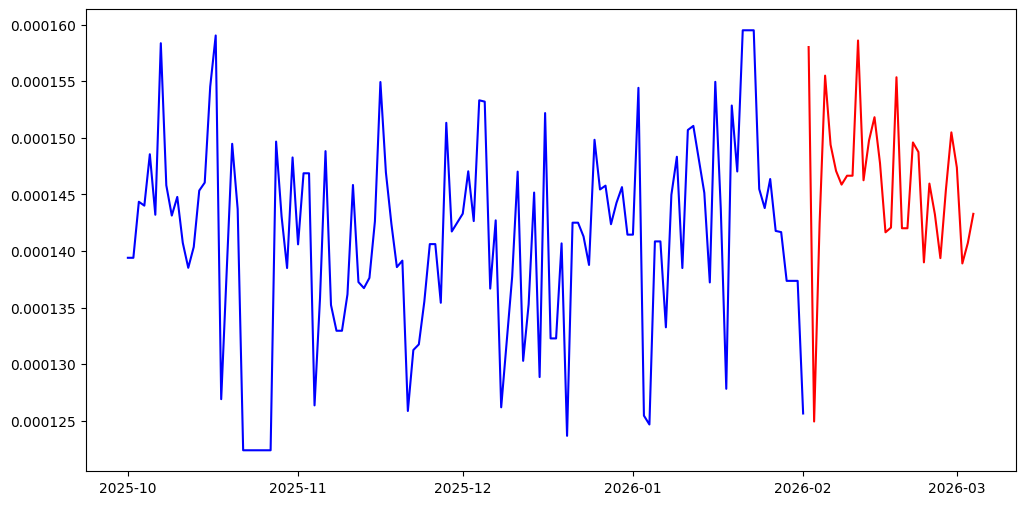

In [52]:
import torch
from neuralprophet import NeuralProphet, set_log_level


df_np_fez = df_fez_day.reset_index()[['day', 't1']]
df_np_fez.columns = ['ds', 'y']

split = int(0.8 * df_np_fez.shape[0])
train_set, test_set = df_np_fez.iloc[:split], df_np_fez.iloc[split:]

plt.figure(figsize=(12,6))
plt.plot(train_set['ds'], train_set['y'], c='blue')
plt.plot(test_set['ds'], test_set['y'], c='red')

In [53]:
m = NeuralProphet()
metrics = m.fit(train_set, freq='D')

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.


INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.194% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.utils.set_auto_seasonalities) - Disabling yearly seasonality. Run NeuralProphet with yearly_seasonality=True to override this.
INFO - (NP.utils.set_auto_seasonalities) - Disabling daily seasonality. Run NeuralProphet with daily_seasonality=True to override this.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 16
INFO - (NP.config.set_auto_batch_epoch) - Auto-set epochs to 230


Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (8) is too small than the required number                     for the learning rate finder (208). The results might not be optimal.
WARNING - (py.warnings._showwarnmsg) - /home/gwenn/Desktop/Projet/.neuralenv/lib/python3.11/site-packages/pytorch_lightning/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 16. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.

WARNING - (py.warnings._showwarnmsg) - /home/gwenn/Desktop/Projet/.neuralenv/lib/python3.11/site-packages/pytorch_lightning/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 12. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.

Finding best initial lr: 100%|██████████| 208/208 [00:00<00:00, 260.18it/s]


Training: |          | 0/? [00:06<?, ?it/s, v_num=68, train_loss=0.0666, reg_loss=0.000, MAE=6.09e-6, RMSE=7.81e-6, Loss=0.067, RegLoss=0.000] 


INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.194% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.355% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.355% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.data.processing._handle_missing_data) - Dropped 31 rows at the end with NaNs in 'y' column.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 536.15it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


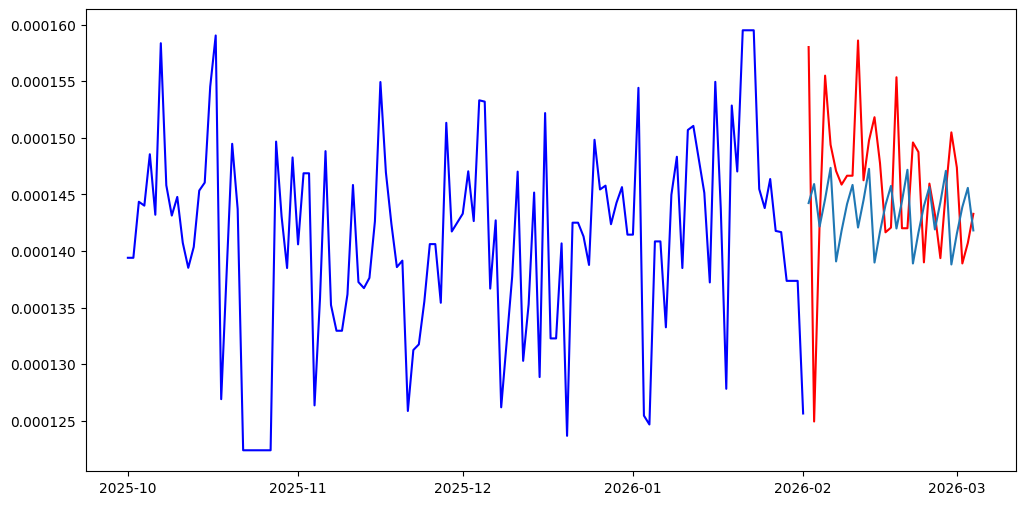

In [54]:
df = train_set.copy()
df_future = m.make_future_dataframe(df, n_historic_predictions=True, periods=len(test_set))
forecast = m.predict(df_future)

plt.figure(figsize=(12,6))
plt.plot(train_set['ds'], train_set['y'], c='blue')
plt.plot(test_set['ds'], test_set['y'], c='red')
plt.plot(forecast['ds'][len(train_set):], forecast['yhat1'][len(train_set):])

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.194% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 16
INFO - (NP.config.set_auto_batch_epoch) - Auto-set epochs to 230


Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (8) is too small than the required number                     for the learning rate finder (208). The results might not be optimal.
Finding best initial lr: 100%|██████████| 208/208 [00:00<00:00, 309.46it/s]


Training: |          | 0/? [00:06<?, ?it/s, v_num=69, train_loss=0.0719, reg_loss=0.000, MAE=6.38e-6, RMSE=8.11e-6, Loss=0.0724, RegLoss=0.000]

INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.194% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 96.774% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 96.774% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 781.35it/s] 

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


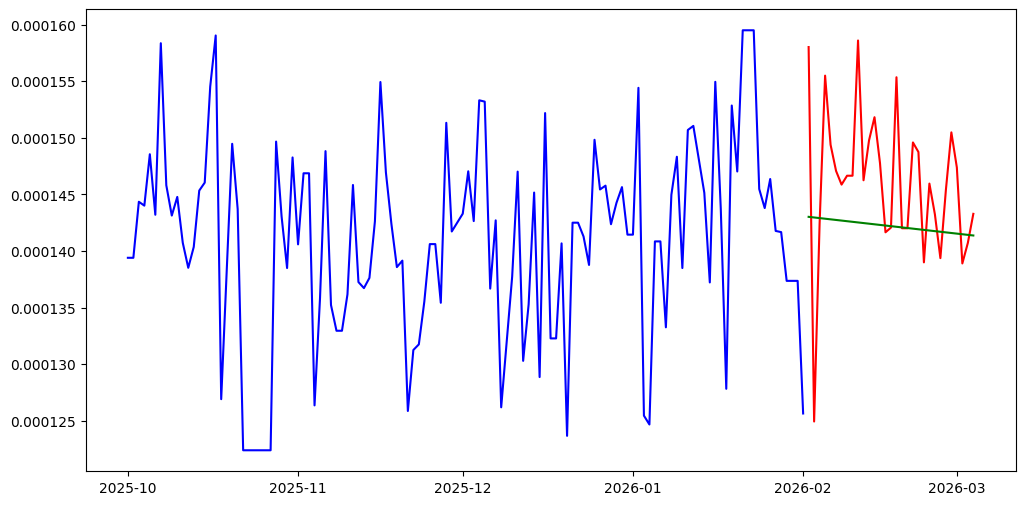

In [55]:
df_np_fez = df_fez_day.reset_index()[['day', 't1']]
df_np_fez.columns = ['ds', 'y']

split = int(0.8 * df_np_fez.shape[0])
train_set, test_set = df_np_fez.iloc[:split], df_np_fez.iloc[split:]
n_preds = len(test_set)

nm = NeuralProphet(
    yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False,
    )
metrics = nm.fit(train_set, freq='D')

df_future = nm.make_future_dataframe(train_set, periods=n_preds)
forecast = nm.predict(df_future)

plt.figure(figsize=(12,6))
plt.plot(train_set['ds'], train_set['y'], c='blue')
plt.plot(test_set['ds'], test_set['y'], c='red')
plt.plot(forecast['ds'], forecast['yhat1'], c='green')
plt.show()

In [56]:
benchmark = pd.read_csv('/home/gwenn/Desktop/Projet/benchmark_results.csv')
benchmark[benchmark['model'] == 'Linear']

,model,backend,metric,steps,mae,rmse,r2,adjusted_r2
0,Linear,ibm_fez,t1,2,0.067026,0.268263,0.903683,0.903421
3,Linear,ibm_fez,t1,10,0.083510,0.274248,0.892676,0.891184
6,Linear,ibm_fez,t1,24,0.071447,0.241590,0.908571,0.905396
9,Linear,ibm_fez,t2,2,0.081682,0.276858,0.864450,0.864081
12,Linear,ibm_fez,t2,10,0.063380,0.238594,0.894446,0.892978
...,...,...,...,...,...,...,...,...
201,Linear,ibm_marrakesh,cz_error,10,0.042913,0.209866,0.908436,0.907163
204,Linear,ibm_marrakesh,cz_error,24,0.050696,0.215322,0.905150,0.901856
207,Linear,ibm_marrakesh,rzz_error,2,0.102755,0.418513,0.833458,0.833005
210,Linear,ibm_marrakesh,rzz_error,10,0.114454,0.431465,0.824851,0.822415


## Model performance

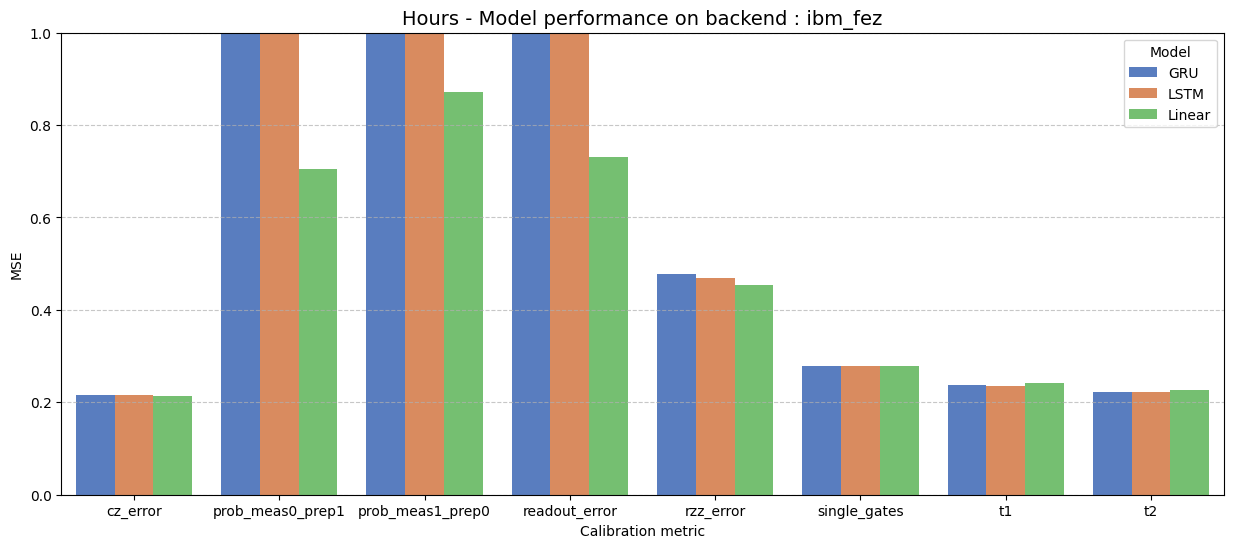

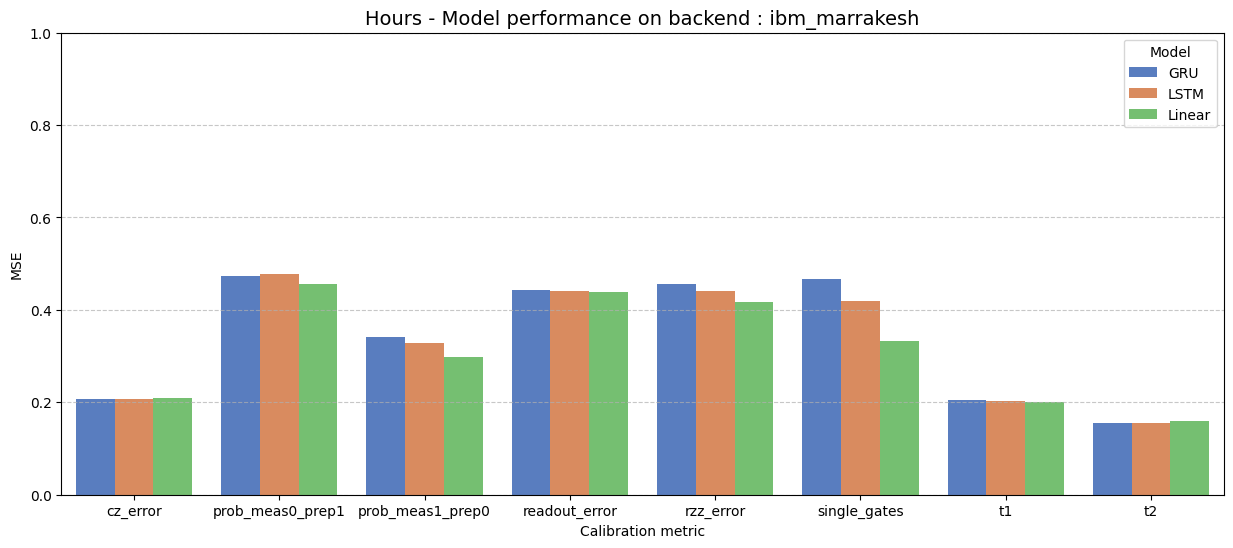

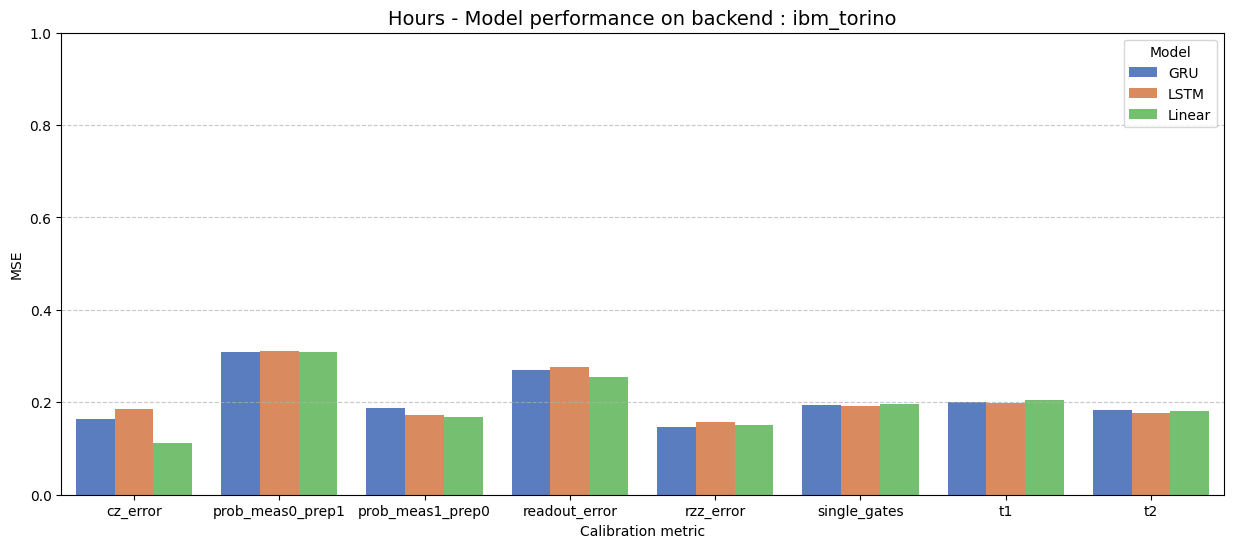

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('benchmark_results.csv')
best_perfs = df.groupby(['model', 'backend', 'metric'])['rmse'].min().reset_index()
backends = best_perfs['backend'].unique()

for b in backends:
    plt.figure(figsize=(15, 6))
    data_backend = best_perfs[best_perfs['backend'] == b]
    
    sns.barplot(
        data=data_backend, 
        x='metric', 
        y='rmse', 
        hue='model',
        palette="muted"
    )
    
    plt.title(f"Hours - Model performance on backend : {b}", fontsize=14)
    plt.ylabel("MSE")
    plt.xlabel("Calibration metric")
    plt.ylim(0, 1)
    plt.legend(title="Model")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.show()

In [58]:
## Hourly
best_perfs = df[df['mae'] == df.groupby(['model', 'backend', 'metric'])['mae'].transform('min')].reset_index()
mean_perfs = best_perfs.groupby(['model', 'metric'])[['mae', 'rmse', 'r2', 'adjusted_r2']].mean().reset_index()
mean_perfs

,model,metric,mae,rmse,r2,adjusted_r2
0,GRU,cz_error,0.080918,0.194505,0.901162,0.900394
1,GRU,prob_meas0_prep1,1.012279,1.217746,-1.424512,-1.434289
2,GRU,prob_meas1_prep0,0.981118,1.086930,-1.923564,-1.961465
3,GRU,readout_error,1.114524,1.278588,-2.158067,-2.168896
4,GRU,rzz_error,0.101647,0.360340,0.843447,0.840808
5,GRU,single_gates,0.112702,0.312531,0.906493,0.903921
6,GRU,t1,0.060973,0.214461,0.932671,0.931313
7,GRU,t2,0.054723,0.191808,0.932190,0.931476
8,LSTM,cz_error,0.081843,0.211521,0.870829,0.869033
9,LSTM,prob_meas0_prep1,1.057540,1.275724,-1.676930,-1.715294


In [59]:
benchmark_day = pd.read_csv('/home/gwenn/Desktop/Projet/day_benchmark_results.csv')
benchmark_day

,model,backend,metric,steps,mae,rmse,r2,adjusted_r2
0,Linear,fez,t1,2,0.612618,0.791043,-0.904814,-1.051338
1,LSTM,fez,t1,2,0.617022,0.791900,-0.908939,-1.055781
2,GRU,fez,t1,2,0.602652,0.779953,-0.851779,-0.994224
3,Linear,fez,t1,10,0.752845,0.906445,-2.024896,-5.049792
4,LSTM,fez,t1,10,0.689542,0.850563,-1.663423,-4.326846
...,...,...,...,...,...,...,...,...
211,LSTM,marrakesh,rzz_error,10,0.777412,1.249378,0.009548,-0.980903
212,GRU,marrakesh,rzz_error,10,0.731102,1.243283,0.019189,-0.961621
213,Linear,marrakesh,rzz_error,24,1.339423,2.059160,-0.057084,1.352361
214,LSTM,marrakesh,rzz_error,24,1.049632,1.987140,0.015566,1.328145


In [75]:
## Day
best_perfs = benchmark_day[benchmark_day['steps'] == benchmark_day.groupby(['model', 'backend', 'metric'])['steps'].transform('min')].reset_index()
mean_perfs = best_perfs.groupby(['model', 'metric'])[['mae', 'rmse', 'r2', 'adjusted_r2']].mean().reset_index()
mean_perfs

,model,metric,mae,rmse,r2,adjusted_r2
0,GRU,cz_error,0.798059,0.923890,-2.646206,-2.926683
1,GRU,prob_meas0_prep1,1.865817,2.016298,-10.492255,-11.376275
2,GRU,prob_meas1_prep0,2.139422,2.262143,-11.401892,-12.355884
3,GRU,readout_error,1.642918,1.763933,-8.161744,-8.866493
4,GRU,rzz_error,0.725468,1.059902,-1.304928,-1.482230
5,GRU,single_gates,0.860251,1.100791,-0.045958,-0.126416
6,GRU,t1,0.675375,0.808808,-0.373658,-0.479324
7,GRU,t2,0.650181,0.849754,-0.341206,-0.444376
8,LSTM,cz_error,0.833995,0.953679,-3.257779,-3.585301
9,LSTM,prob_meas0_prep1,1.806347,1.958808,-9.697412,-10.520289


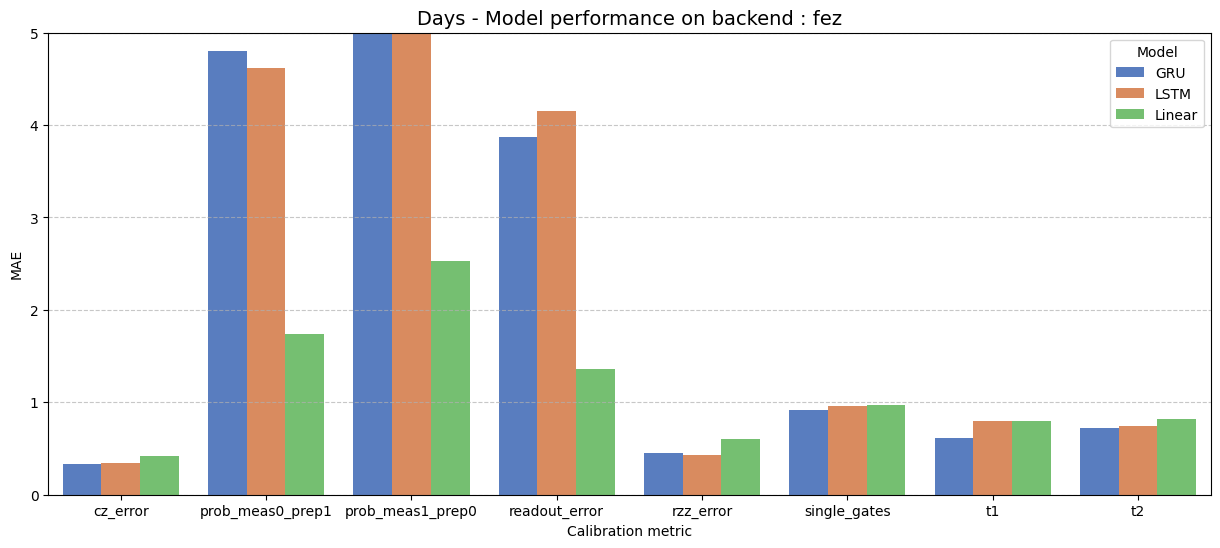

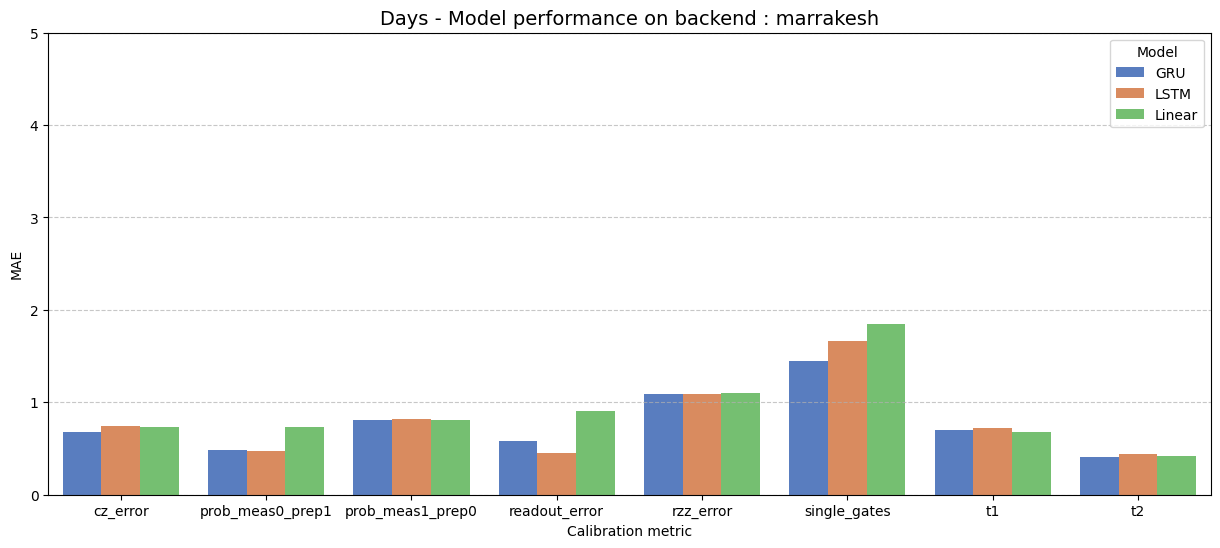

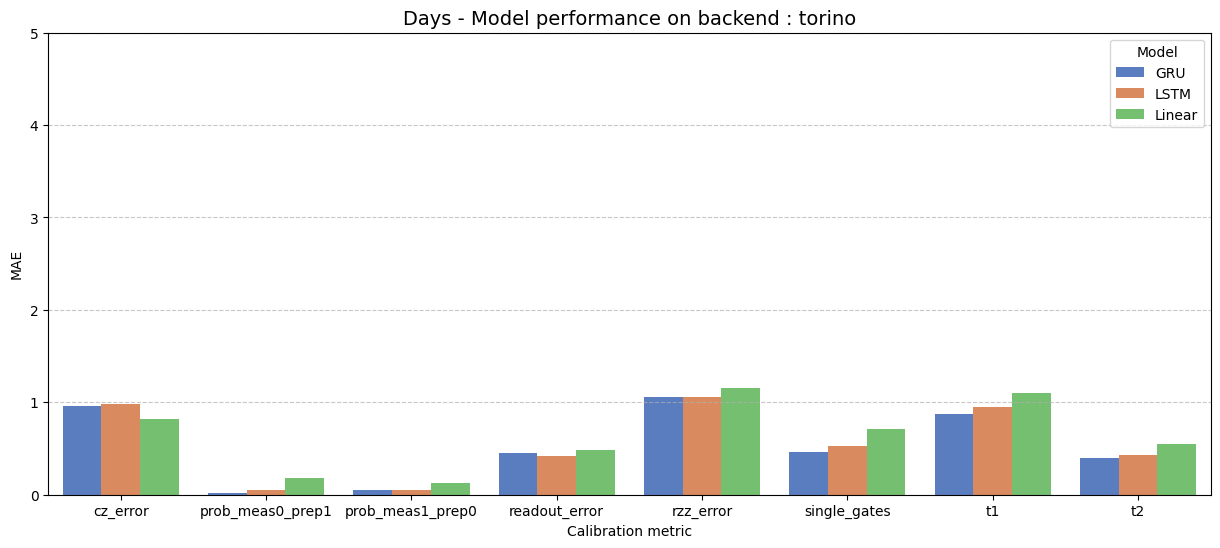

In [61]:
## Day
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

best_perfs = benchmark_day.groupby(['model', 'backend', 'metric'])['rmse'].min().reset_index()
backends = best_perfs['backend'].unique()

for b in backends:
    plt.figure(figsize=(15, 6))
    data_backend = best_perfs[best_perfs['backend'] == b]
    
    sns.barplot(
        data=data_backend, 
        x='metric', 
        y='rmse', 
        hue='model',
        palette="muted"
    )
    
    plt.title(f"Days - Model performance on backend : {b}", fontsize=14)
    plt.ylabel("MAE")
    plt.xlabel("Calibration metric")
    plt.ylim(0, 5)
    plt.legend(title="Model")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.show()

### In average which one give the best performance

--- PERFORMANCE TABLE ---
model                            GRU      LSTM    Linear
backend   metric                                        
fez       cz_error          0.277801  0.289116  0.345769
          prob_meas0_prep1  4.729387  4.544026  1.474678
          prob_meas1_prep0  5.007432  5.960070  2.368095
          readout_error     3.794447  4.078966  1.184828
          rzz_error         0.439867  0.414247  0.465733
          single_gates      0.714215  0.730411  0.734745
          t1                0.488706  0.617022  0.612618
          t2                0.612766  0.620806  0.698675
marrakesh cz_error          0.567729  0.597615  0.612547
          prob_meas0_prep1  0.419411  0.420870  0.578047
          prob_meas1_prep0  0.561875  0.573222  0.557484
          readout_error     0.531431  0.383414  0.655566
          rzz_error         0.634789  0.626276  0.643107
          single_gates      1.264058  1.354411  1.251879
          t1                0.565762  0.595038  0.535131
     

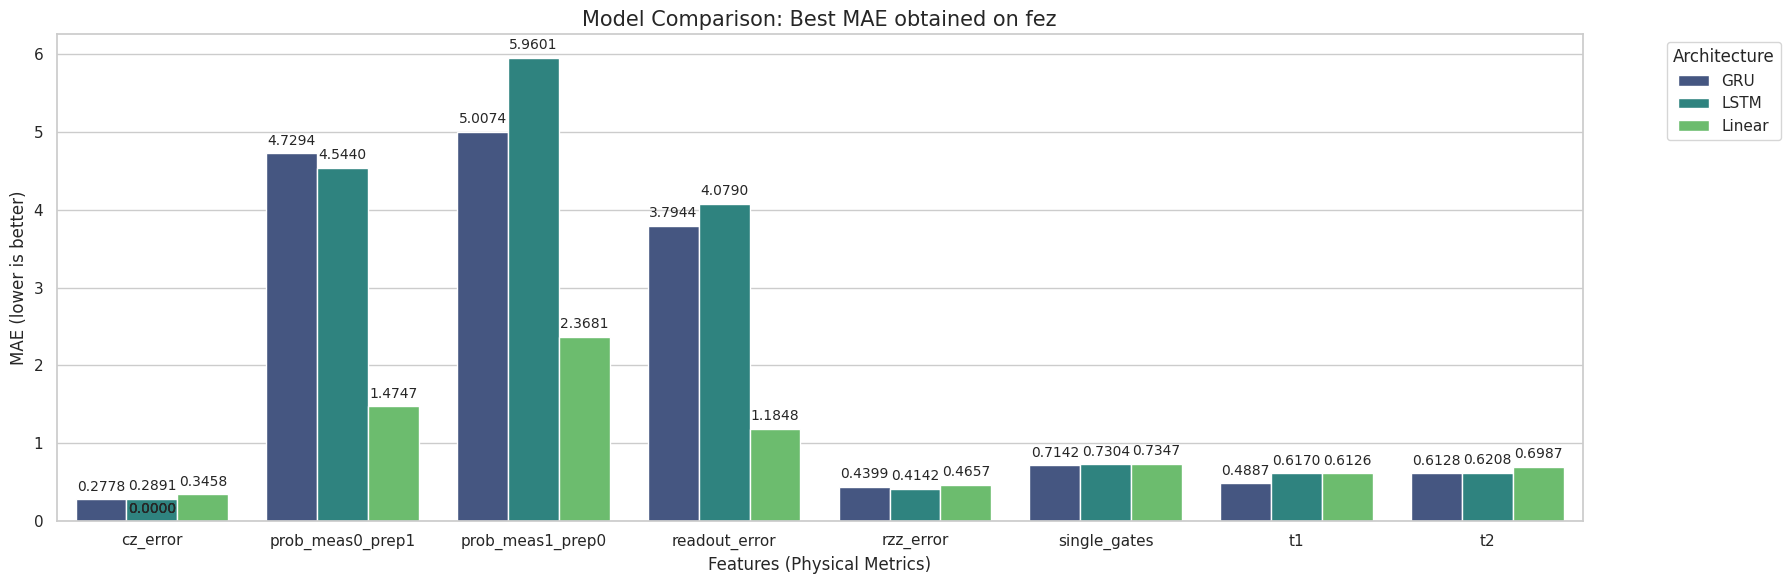

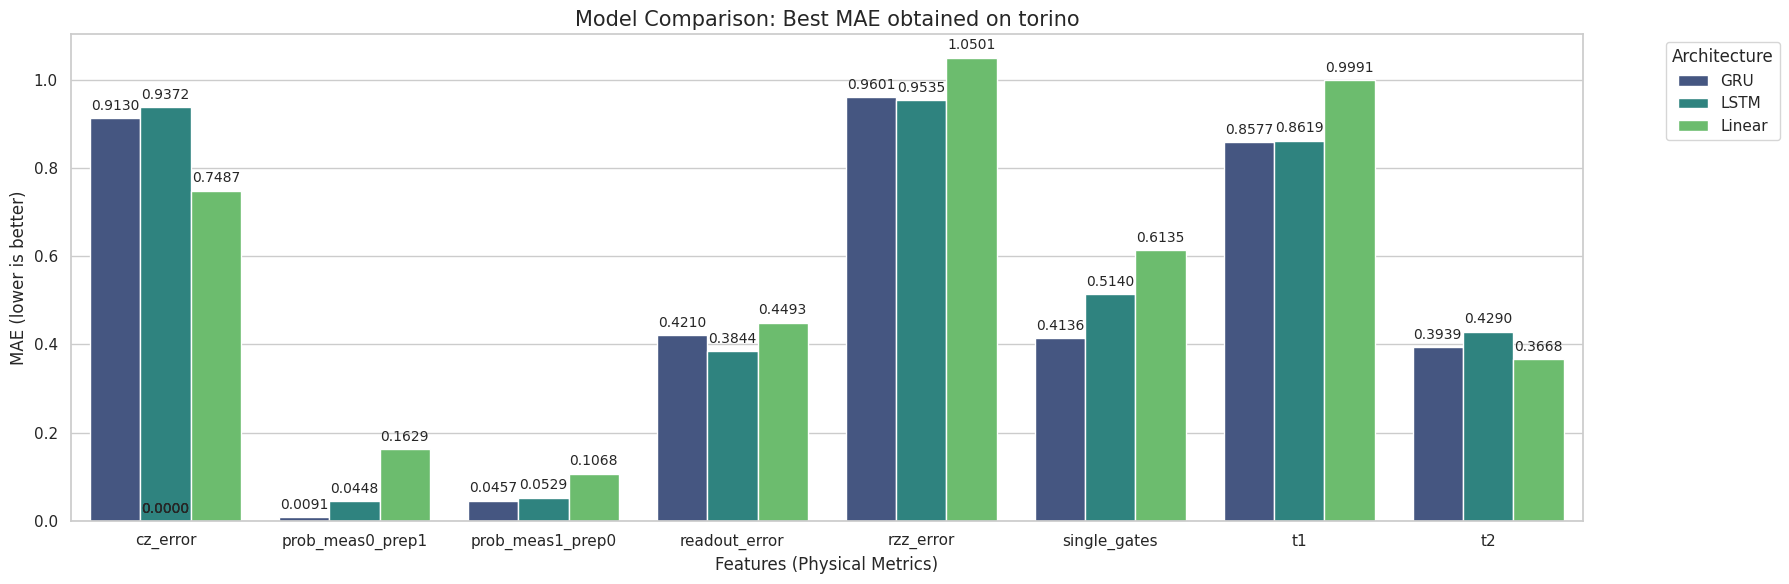

Epoch 90: 100%|██████████| 90/90 [2:18:17<00:00,  0.01it/s]  


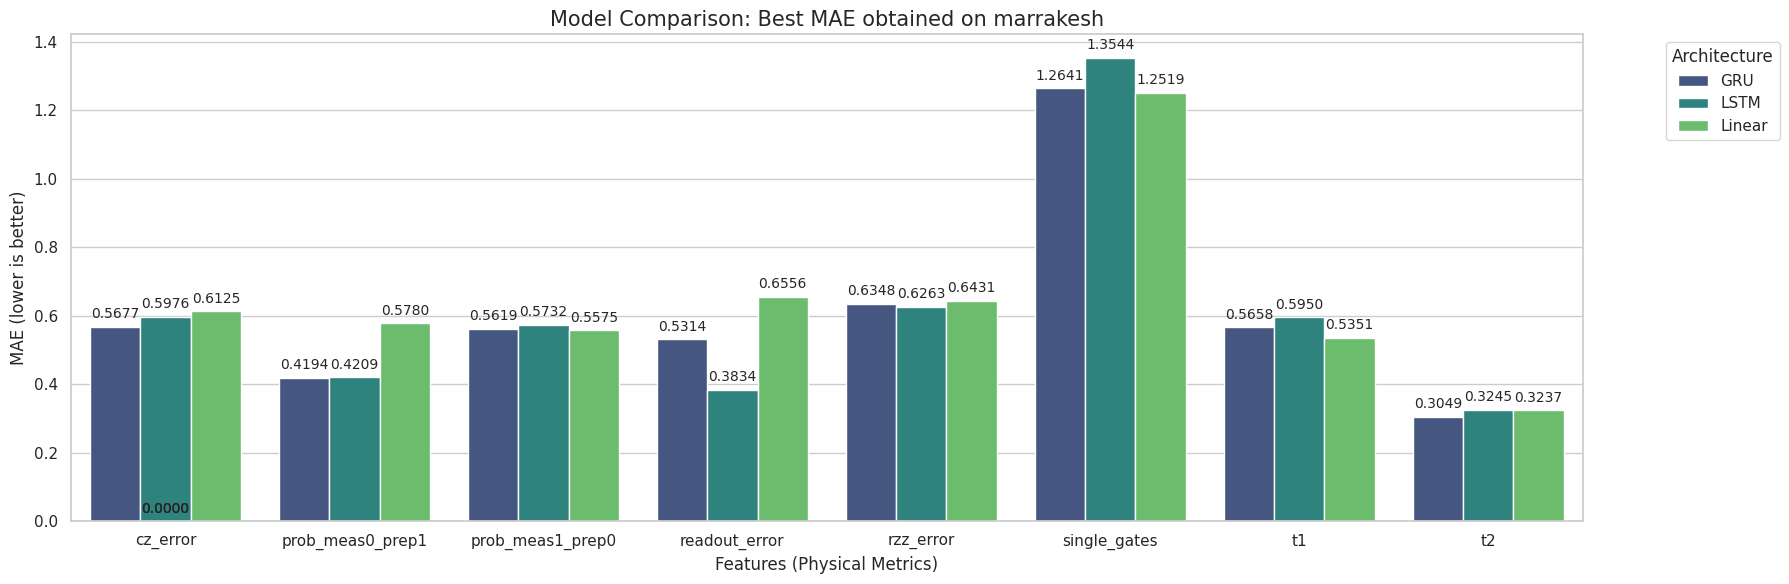

In [76]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('day_benchmark_results.csv')

best_perf_table = df.groupby(['backend', 'metric', 'model'])['mae'].min().unstack()

print("--- PERFORMANCE TABLE ---")
print(best_perf_table)
print("\n")

backends = df['backend'].unique()

sns.set_theme(style="whitegrid")

for backend in backends:
    data_backend = df[df['backend'] == backend]
    
    best_step_data = data_backend.loc[data_backend.groupby(['model', 'metric'])['mae'].idxmin()]
    
    plt.figure(figsize=(18, 6))
    ax = sns.barplot(
        data=best_step_data, 
        x='metric', 
        y='mae', 
        hue='model', 
        palette="viridis"
    )
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.4f'), 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'center', 
                       xytext = (0, 9), 
                       textcoords = 'offset points',
                       fontsize=10)

    plt.title(f"Model Comparison: Best MAE obtained on {backend}", fontsize=15)
    plt.ylabel("MAE (lower is better)")
    plt.xlabel("Features (Physical Metrics)")
    plt.legend(title="Architecture", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    plt.show()

## Neural Network - Daily - T1 - Fez

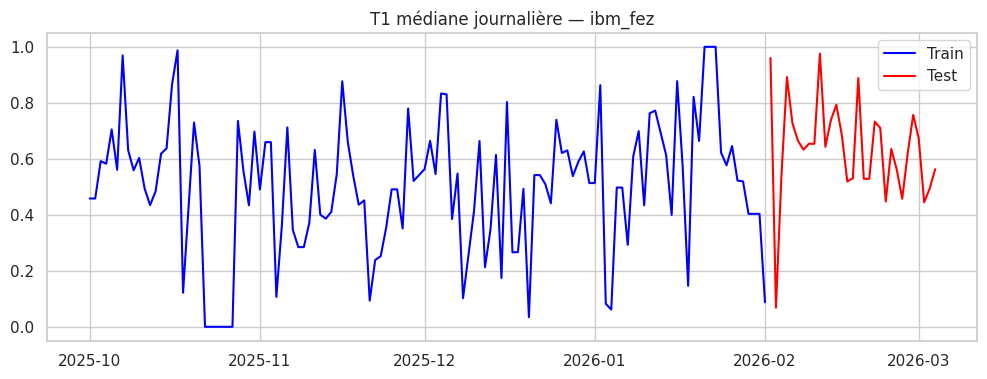

Training: |          | 0/? [00:00<?, ?it/s]

Finding best initial lr: 100%|██████████| 208/208 [00:00<00:00, 260.76it/s]


Training: |          | 0/? [00:09<?, ?it/s, v_num=74, MAE_val=0.166, RMSE_val=0.202, Loss_val=0.134, RegLoss_val=0.000, train_loss=0.0929, reg_loss=0.000, MAE=0.161, RMSE=0.205, Loss=0.0923, RegLoss=0.000]
          MAE      RMSE      Loss   MAE_val  RMSE_val
225  0.159674  0.203516  0.092559  0.165750  0.201689
226  0.164723  0.209788  0.097629  0.165795  0.201738
227  0.159920  0.199904  0.091590  0.165843  0.201811
228  0.157740  0.200944  0.090256  0.165853  0.201855
229  0.161309  0.205312  0.092256  0.165963  0.201967


In [77]:
from neuralprophet import NeuralProphet, set_log_level
from sklearn.preprocessing import MinMaxScaler

set_log_level("ERROR") 

df_np_fez = df_fez_day[['day', 't1']].copy()
df_np_fez.columns = ['ds', 'y']
df_np_fez['ds'] = pd.to_datetime(df_np_fez['ds'])

## Normalising to make the metrics more ''Natural''
scaler = MinMaxScaler()
df_np_fez['y'] = scaler.fit_transform(df_np_fez[['y']])

## train test split
split = int(0.8 * len(df_np_fez))
plt.figure(figsize=(12, 4))
plt.plot(df_np_fez['ds'].iloc[:split], df_np_fez['y'].iloc[:split], c='blue', label='Train')
plt.plot(df_np_fez['ds'].iloc[split:], df_np_fez['y'].iloc[split:], c='red', label='Test')
plt.legend()
plt.title('T1 médiane journalière — ibm_fez')
plt.show()

model = NeuralProphet(
    n_forecasts=1,
    n_lags=7,         
    yearly_seasonality=False,
    weekly_seasonality=True, 
    daily_seasonality=False,
    quantiles=[0.1,0.9]
)

df_train, df_val = model.split_df(df_np_fez, freq='D', valid_p=0.2)
metrics = model.fit(df_train, freq='D', validation_df=df_val)

print(metrics[['MAE', 'RMSE', 'Loss', 'MAE_val', 'RMSE_val']].tail(5))

Predicting DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 491.37it/s]


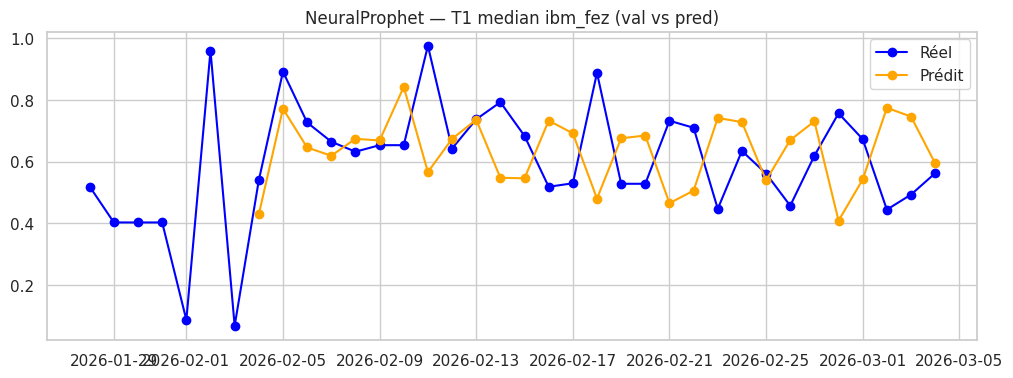

MAE   modèle   : 1.66e-01
MAE   baseline : 1.05e-01  (prédire la moyenne)
RMSE  modèle   : 2.02e-01
Ratio MAE/baseline : 1.58


In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Prédictions sur le jeu de validation
df_pred = model.predict(df_val)

plt.figure(figsize=(12, 4))
plt.plot(df_pred['ds'], df_pred['y'], "o-", label='Réel', color='blue')
plt.plot(df_pred['ds'], df_pred['yhat1'], "o-",   label='Prédit',    color='orange')
plt.legend()
plt.title('NeuralProphet — T1 median ibm_fez (val vs pred)')
plt.savefig('show_neural.jpg')
plt.show()

mask = df_pred['yhat1'].notna() & df_pred['y'].notna()
mae  = mean_absolute_error(df_pred.loc[mask, 'y'], df_pred.loc[mask, 'yhat1'])
rmse = np.sqrt(mean_squared_error(df_pred.loc[mask, 'y'], df_pred.loc[mask, 'yhat1']))
baseline_mae = mean_absolute_error(df_pred.loc[mask, 'y'],
                                   [df_pred.loc[mask, 'y'].mean()] * mask.sum())

print(f"MAE   modèle   : {mae:.2e}")
print(f"MAE   baseline : {baseline_mae:.2e}  (prédire la moyenne)")
print(f"RMSE  modèle   : {rmse:.2e}")
print(f"Ratio MAE/baseline : {mae/baseline_mae:.2f}")



In [79]:
mask = df_pred['yhat1'].notna() & df_pred['y'].notna()
y_true = df_pred.loc[mask, 'y'].values
y_pred = df_pred.loc[mask, 'yhat1'].values

y_naive = df_pred.loc[mask, 'y'].shift(1).dropna().values
y_true_naive = y_true[1:]

mae_model = mean_absolute_error(y_true, y_pred)
mae_naive  = mean_absolute_error(y_true_naive, y_naive)
mae_mean   = mean_absolute_error(y_true, [y_true.mean()] * len(y_true))

print(f"MAE modèle   : {mae_model:.2e}")
print(f"MAE naive    : {mae_naive:.2e}   ← y(t) = y(t-1)")
print(f"MAE moyenne  : {mae_mean:.2e}   ← y(t) = mean")
print(f"\nModèle vs naive : {mae_model/mae_naive:.3f}  (model better if < )")
print(f"\nModèle vs moyenne : {mae_model/mae_mean:.3f}  (model better if < )")

MAE modèle   : 1.66e-01
MAE naive    : 1.44e-01   ← y(t) = y(t-1)
MAE moyenne  : 1.05e-01   ← y(t) = mean

Modèle vs naive : 1.155  (model better if < )

Modèle vs moyenne : 1.582  (model better if < )


<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color:#f0fff0;">

Ce plot arrive a la même conclusion que les précédents modèles, le modèle apprends a prédire t = t-1.  
On remarque tout de même un pattern tel que si la valeur est au dessus de la moyenne a un certain degrès il va chercher a redescendre.

## Generalising inside a function

In [ ]:
def neuralProphMetricsComputation(df, feature):
    set_log_level("ERROR") 

    df_np_fez = df[['day', feature]].copy()
    df_np_fez.columns = ['ds', 'y']
    df_np_fez['ds'] = pd.to_datetime(df_np_fez['ds'])

    ## Normalising to make the metrics more ''Natural''
    scaler = MinMaxScaler()
    df_np_fez['y'] = scaler.fit_transform(df_np_fez[['y']])

    n = len(df_np_fez)
    df_trainval = df_np_fez.iloc[:int(n * 0.8)]  # 80%
    df_test = df_np_fez.iloc[int(n * 0.8):]  # 20%

    ## train test split
    split = int(0.8 * len(df_np_fez))
    plt.figure(figsize=(12, 4))
    plt.plot(df_trainval['ds'], df_trainval['y'], c='blue', label='Train')
    plt.plot(df_test['ds'], df_test['y'], c='red', label='Test')
    plt.legend()
    plt.title(f'{feature} médiane journalière')
    plt.show()

    model = NeuralProphet(
        n_forecasts=1,
        n_lags=7,         
        yearly_seasonality=False,
        weekly_seasonality=False, 
        daily_seasonality=False,
        quantiles=[0.1,0.9]
    )

    df_train, df_val = model.split_df(df_trainval, freq='D', valid_p=0.2)
    metrics = model.fit(df_train, freq='D', validation_df=df_val)

    print(metrics[['MAE', 'RMSE', 'Loss', 'MAE_val', 'RMSE_val']].tail(5))

    ''' ---- Prediction ---- '''

    df_pred = model.predict(df_test)

    plt.figure(figsize=(12, 4))
    plt.plot(df_pred['ds'], df_pred['y'], "o-", label='Réel', color='blue')
    plt.plot(df_pred['ds'], df_pred['yhat1'], "o-",   label='Prédit',    color='orange')
    plt.legend()
    plt.title(f'NeuralProphet — {feature} median (val vs pred)')
    plt.savefig('show_neural.jpg')
    plt.show()

    mask = df_pred['yhat1'].notna() & df_pred['y'].notna()
    mae  = mean_absolute_error(df_pred.loc[mask, 'y'], df_pred.loc[mask, 'yhat1'])
    rmse = np.sqrt(mean_squared_error(df_pred.loc[mask, 'y'], df_pred.loc[mask, 'yhat1']))
    baseline_mae = mean_absolute_error(df_pred.loc[mask, 'y'], [df_pred.loc[mask, 'y'].mean()] * mask.sum())

    print(f"MAE   modèle   : {mae:.2e}")
    print(f"MAE   baseline : {baseline_mae:.2e}  (prédire la moyenne)")
    print(f"RMSE  modèle   : {rmse:.2e}")
    print(f"Ratio MAE/baseline : {mae/baseline_mae:.2f}")

    ### Comparing model with naive and median method
    
    mask = df_pred['yhat1'].notna() & df_pred['y'].notna()
    y_true = df_pred.loc[mask, 'y'].values
    y_pred = df_pred.loc[mask, 'yhat1'].values

    y_naive = df_pred.loc[mask, 'y'].shift(1).dropna().values
    y_true_naive = y_true[1:]

    mae_model = mean_absolute_error(y_true, y_pred)
    mae_naive  = mean_absolute_error(y_true_naive, y_naive)
    mae_mean   = mean_absolute_error(y_true, [y_true.mean()] * len(y_true))

    print(f"MAE modèle   : {mae_model:.2e}")
    print(f"MAE naive    : {mae_naive:.2e}   ← y(t) = y(t-1)")
    print(f"MAE moyenne  : {mae_mean:.2e}   ← y(t) = mean")
    print(f"\nModèle vs naive : {mae_model/mae_naive:.3f}  (model better if < 1)")
    print(f"\nModèle vs moyenne : {mae_model/mae_mean:.3f}  (model better if < 1)")

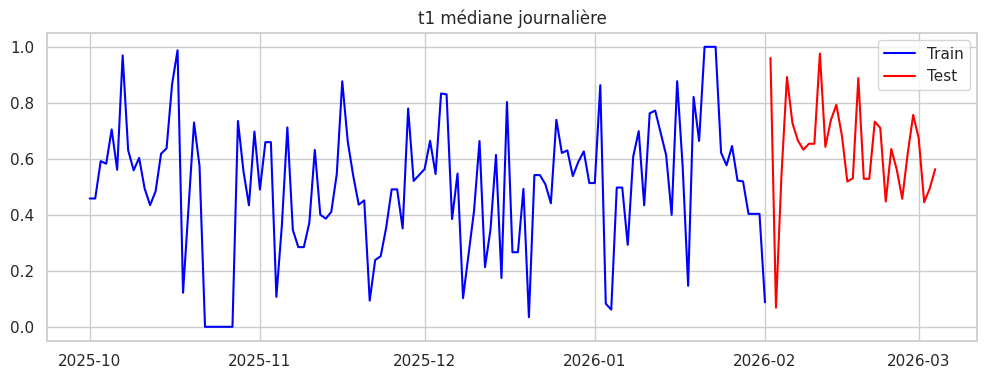

Training: |          | 0/? [00:00<?, ?it/s]

Finding best initial lr: 100%|██████████| 207/207 [00:00<00:00, 299.73it/s]


Training: |          | 0/? [00:13<?, ?it/s, v_num=75, MAE_val=0.193, RMSE_val=0.228, Loss_val=0.186, RegLoss_val=0.000, train_loss=0.107, reg_loss=0.000, MAE=0.166, RMSE=0.215, Loss=0.108, RegLoss=0.000]
          MAE      RMSE      Loss   MAE_val  RMSE_val
245  0.166765  0.216208  0.108121  0.193377  0.228113
246  0.166109  0.215045  0.106996  0.193366  0.228106
247  0.166637  0.213878  0.107188  0.193384  0.228114
248  0.164232  0.208715  0.106046  0.193332  0.228085
249  0.166401  0.215029  0.108030  0.193351  0.228096
Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 601.59it/s]


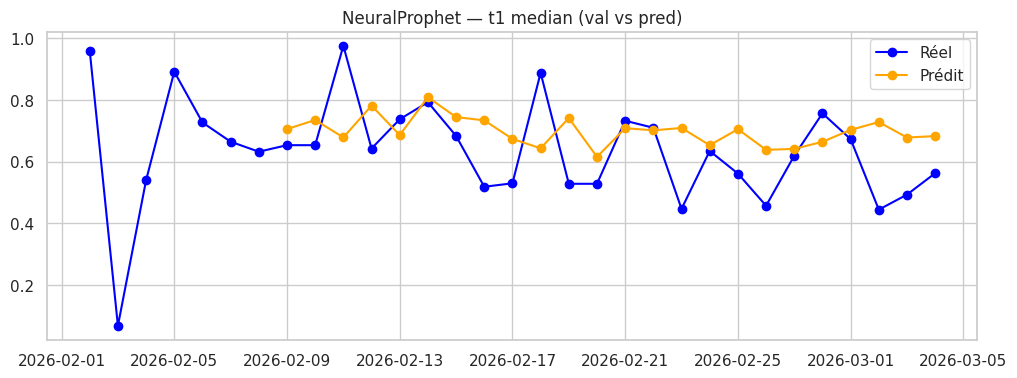

MAE   modèle   : 1.24e-01
MAE   baseline : 1.07e-01  (prédire la moyenne)
RMSE  modèle   : 1.53e-01
Ratio MAE/baseline : 1.16
MAE modèle   : 1.24e-01
MAE naive    : 1.47e-01   ← y(t) = y(t-1)
MAE moyenne  : 1.07e-01   ← y(t) = mean

Modèle vs naive : 0.840  (model better if < 1)

Modèle vs moyenne : 1.155  (model better if < 1)


In [81]:
neuralProphMetricsComputation(df_fez_day, 't1')

In [ ]:
### Benchmark loop 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
n = len(y_true) # On a len(y_true) prédiction et a chaque fois 1 seule valeurs de prédite
k = step # Mon nombre de features 
adj_r2 = 1 - ((1-r2)*(n-1))/(n-k-1) ## Formule du Adjusted-R-Squared
benchmark.append({
    "model": model_name,
    'backend': backend['backend'].unique()[0],
    "metric": metric,
    "steps": step,
    "mae": mae,
    "rmse": rmse,
    "r2" : r2,
    "adjusted_r2": adj_r2    
})


### Hourly prediction

In [84]:
def neuralProphMetricsComputation_hour(df, feature):
    set_log_level("ERROR") 

    df_np = df[['calibration_time', feature]].copy()
    df_np.columns = ['ds', 'y']
    df_np['ds'] = pd.to_datetime(df_np['ds'])

    ## Normalising to make the metrics more ''Natural''
    scaler = MinMaxScaler()
    df_np['y'] = scaler.fit_transform(df_np[['y']])

    n = len(df_np)
    df_trainval = df_np.iloc[:int(n * 0.8)]  # 80%
    df_test = df_np.iloc[int(n * 0.8):]  # 20%

    ## train test split
    split = int(0.8 * len(df_np))
    plt.figure(figsize=(12, 4))
    plt.plot(df_trainval['ds'], df_trainval['y'], c='blue', label='Train')
    plt.plot(df_test['ds'], df_test['y'], c='red', label='Test')
    plt.legend()
    plt.title(f'{feature} médiane journalière')
    plt.show()

    model = NeuralProphet(
        n_forecasts=1,
        n_lags=48, ## I take 2 days as a frequency
        yearly_seasonality=False,
        weekly_seasonality=False, 
        daily_seasonality=True,
        quantiles=[0.1,0.9]
    )

    df_train, df_val = model.split_df(df_trainval, freq='h', valid_p=0.2)
    metrics = model.fit(df_train, freq='h', validation_df=df_val)

    print(metrics[['MAE', 'RMSE', 'Loss', 'MAE_val', 'RMSE_val']].tail(5))

    ''' ---- Prediction ---- '''

    df_pred = model.predict(df_test)

    plt.figure(figsize=(12, 4))
    plt.plot(df_pred['ds'], df_pred['y'], label='Réel', color='blue')
    plt.plot(df_pred['ds'], df_pred['yhat1'],   label='Prédit',    color='orange')
    plt.legend()
    plt.title(f'NeuralProphet — {feature} median (val vs pred)')
    plt.savefig('show_neural.jpg')
    plt.show()

    mask = df_pred['yhat1'].notna() & df_pred['y'].notna()
    mae  = mean_absolute_error(df_pred.loc[mask, 'y'], df_pred.loc[mask, 'yhat1'])
    rmse = np.sqrt(mean_squared_error(df_pred.loc[mask, 'y'], df_pred.loc[mask, 'yhat1']))
    baseline_mae = mean_absolute_error(df_pred.loc[mask, 'y'], [df_pred.loc[mask, 'y'].mean()] * mask.sum())

    print(f"MAE   modèle   : {mae:.2e}")
    print(f"MAE   baseline : {baseline_mae:.2e}  (prédire la moyenne)")
    print(f"RMSE  modèle   : {rmse:.2e}")
    print(f"Ratio MAE/baseline : {mae/baseline_mae:.2f}")

    ### Comparing model with naive and median method
    
    mask = df_pred['yhat1'].notna() & df_pred['y'].notna()
    y_true = df_pred.loc[mask, 'y'].values
    y_pred = df_pred.loc[mask, 'yhat1'].values

    y_naive = df_pred.loc[mask, 'y'].shift(1).dropna().values
    y_true_naive = y_true[1:]

    mae_model = mean_absolute_error(y_true, y_pred)
    mae_naive  = mean_absolute_error(y_true_naive, y_naive)
    mae_mean   = mean_absolute_error(y_true, [y_true.mean()] * len(y_true))

    print(f"MAE modèle   : {mae_model:.2e}")
    print(f"MAE naive    : {mae_naive:.2e}   ← y(t) = y(t-1)")
    print(f"MAE moyenne  : {mae_mean:.2e}   ← y(t) = mean")
    print(f"\nModèle vs naive : {mae_model/mae_naive:.3f}  (model better if < 1)")
    print(f"\nModèle vs moyenne : {mae_model/mae_mean:.3f}  (model better if < 1)")

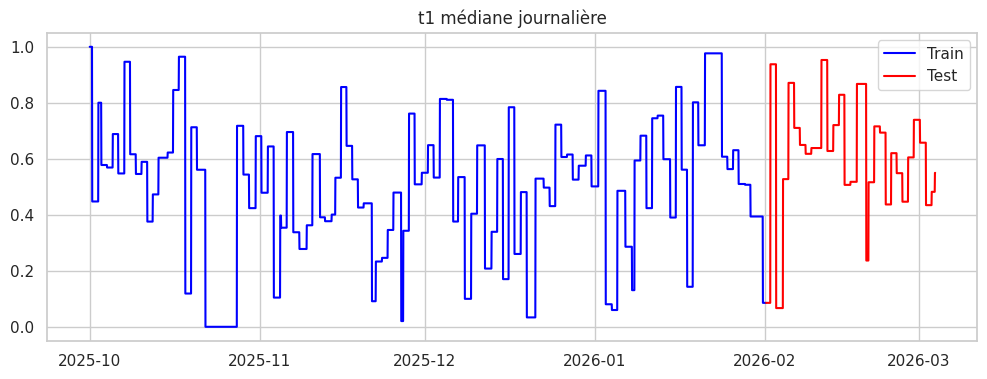

Training: |          | 0/? [00:00<?, ?it/s]

Finding best initial lr: 100%|██████████| 234/234 [00:02<00:00, 116.70it/s]


Training: |          | 0/? [00:32<?, ?it/s, v_num=77, MAE_val=0.0379, RMSE_val=0.0713, Loss_val=0.0198, RegLoss_val=0.000, train_loss=0.0147, reg_loss=0.000, MAE=0.0372, RMSE=0.0671, Loss=0.0146, RegLoss=0.000]
         MAE      RMSE      Loss   MAE_val  RMSE_val
85  0.037088  0.065760  0.014574  0.037945  0.071320
86  0.037312  0.067380  0.014808  0.038006  0.071329
87  0.036978  0.066984  0.014604  0.037949  0.071307
88  0.036955  0.066998  0.014558  0.037904  0.071294
89  0.037151  0.067086  0.014562  0.037908  0.071285
Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 140.62it/s]


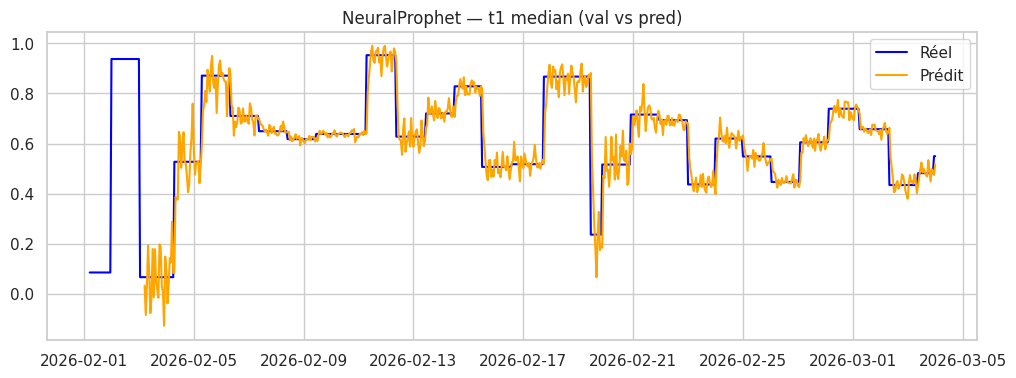

MAE   modèle   : 3.66e-02
MAE   baseline : 1.32e-01  (prédire la moyenne)
RMSE  modèle   : 6.56e-02
Ratio MAE/baseline : 0.28
MAE modèle   : 3.66e-02
MAE naive    : 7.32e-03   ← y(t) = y(t-1)
MAE moyenne  : 1.32e-01   ← y(t) = mean

Modèle vs naive : 4.999  (model better if < 1)

Modèle vs moyenne : 0.276  (model better if < 1)


In [85]:
neuralProphMetricsComputation_hour(df_fez, 't1')